# Peak alpha frequency: measured C3/C4/Cz features

[Furman et al., 2019](https://pmc.ncbi.nlm.nih.gov/articles/PMC6843105/) uses **9–11 Hz power-weighted center of gravity**, not an argmax. We use five-second symmetric-Hann epochs and 0.2-Hz bins, average epoch centroids per channel, then average C3/C4/Cz. Existing PCA-free preprocessing is retained. These are selected excerpts, not verified pain-free baselines. Read `paf_report.md` before interpreting the values.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display
candidates = (Path.cwd(), Path.cwd() / 'paf_results', Path.cwd() / 'eeg-analysis' / 'paf_results')
BASE = next(p for p in candidates if (p / 'summary.csv').is_file())
summary = pd.read_csv(BASE / 'summary.csv')
print('Measured recordings:', len(summary))
print('Retained five-second epochs:', summary.epochs_used.sum())
display(summary.round(3))

Measured recordings: 8
Retained five-second epochs: 411


,recording,epochs_used,epochs_rejected,roi_cog_9_11_hz,C3_cog_hz,C4_cog_hz,CZ_cog_hz,second_minus_first_half_hz,channels_with_qualified_peak
0,ds005292,60,0,9.982,9.976,9.978,9.992,0.028,3
1,ds005293,60,0,10.060,10.069,10.117,9.992,-0.069,3
2,ds005289,41,0,10.205,10.159,10.226,10.229,0.086,3
3,ds005286,60,0,10.108,10.158,10.080,10.084,0.106,3
4,ds005284,59,1,10.112,10.131,10.061,10.145,-0.024,3
5,ds005307,13,1,10.002,10.025,9.984,9.997,-0.071,3
6,osf-sub008-ec,60,0,9.751,9.798,9.694,9.761,0.139,3
7,osf-sub008-eo,58,2,9.898,9.929,9.826,9.938,-0.121,3


## Spectral inspection

The shaded band may not contain a recording's strongest alpha peak. A centroid still exists in a sloped spectrum; it is not proof of an oscillation.

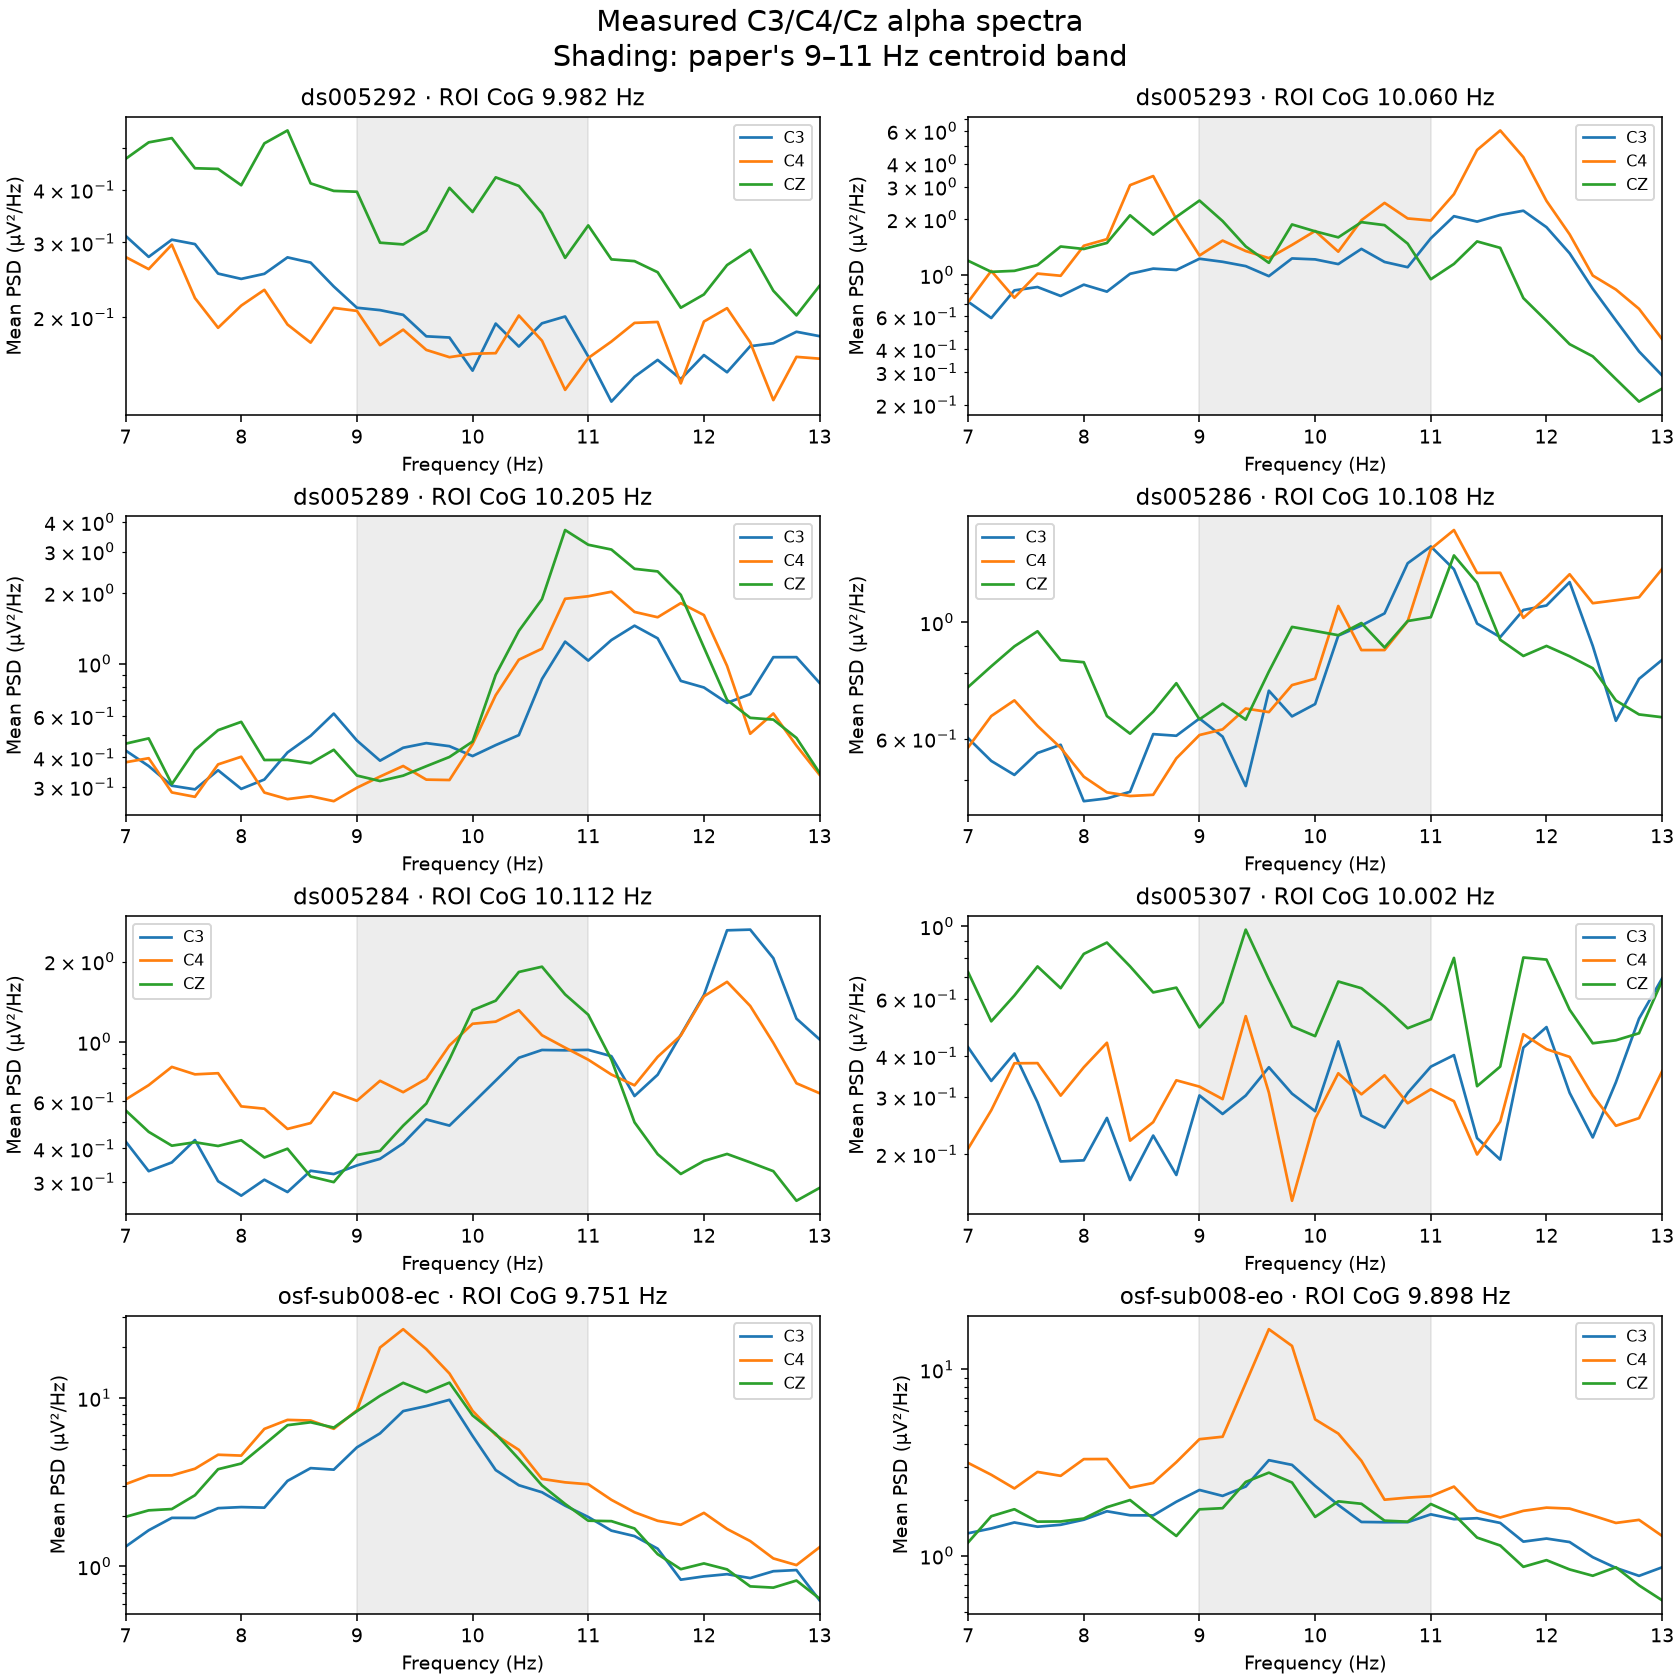

In [2]:
import json
results = json.loads((BASE / 'results.json').read_text())
rows = [dict(recording=r['key'], channel=ch, **values)
        for r in results if r['status']=='analyzed'
        for ch, values in r['channels'].items()]
display(pd.DataFrame(rows).round(3))

,recording,channel,cog_9_11_hz,cog_8_12_hz,argmax_8_12_hz,qualified_local_peak_hz,local_peak_prominence_db,epoch_sd_hz
0,ds005292,C3,9.976,9.798,8.4,10.8,1.278,0.246
1,ds005292,C4,9.978,9.937,8.2,11.6,1.450,0.226
2,ds005292,CZ,9.992,9.801,8.4,8.4,1.292,0.220
3,ds005293,C3,10.069,10.382,11.8,11.8,5.793,0.287
4,ds005293,C4,10.117,10.549,11.6,11.6,9.263,0.266
5,ds005293,CZ,9.992,9.967,9.0,9.0,3.848,0.275
6,ds005289,C3,10.159,10.311,11.4,11.4,3.282,0.325
7,ds005289,C4,10.226,10.512,11.2,11.2,7.788,0.268
8,ds005289,CZ,10.229,10.341,10.8,10.8,10.329,0.325
9,ds005286,C3,10.158,10.293,11.0,11.0,3.330,0.289


## Reproduce

Run `python paf_features.py`, then `python paf_outputs.py` from `eeg-analysis/paf_results/`. Raw binaries are SHA-256 verified first. The per-epoch CSV files retain original epoch indices and onset times, including gaps after rejection. `qualified_local_peak_hz` is a secondary 8–12 Hz local peak with a heuristic ≥1 dB prominence in the mean spectrum; it is neither the paper's feature nor a validated alpha-quality classifier. Missing peaks are left empty, not filled at 10 Hz. No pain correlation is fitted.